In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
GITHUB_USER = user_secrets.get_secret("GITHUB_USER")
GITHUB_TOKEN = user_secrets.get_secret("GITHUB_TOKEN")
ROOT_DIR = "/kaggle/working/"

In [24]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")
login(token=secret_value_0)

In [2]:
!pip install timm rasterio gradio huggingface_hub safetensors

In [3]:
import ast
import re
import hashlib
import json
import os
import random
import shutil
import time
import warnings
import zipfile
from collections import defaultdict
from dataclasses import dataclass, asdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import rasterio
from rasterio.enums import Resampling
import timm, torch
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file as load_safetensors
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

In [4]:
@dataclass
class Config:
    DATA_ROOT: Path=Path("/kaggle/input/datasets/glitchr/bigearthnet-48k-subset")
    OUTPUT_DIR: Path=Path("/kaggle/working/outputs")
    MODEL_NAME: str="vit_base_patch8_224"
    EMBED_DIM: int=256
    IMAGE_SIZE: int=120
    LOCAL_PRETRAINED_PATH: str|None=None
    USE_HF_REBEN: bool=True
    HF_S1_REPO: str="BIFOLD-BigEarthNetv2-0/vit_base_patch8_224-s1-v0.1.1"
    HF_S2_REPO: str="BIFOLD-BigEarthNetv2-0/vit_base_patch8_224-s2-v0.1.1"
    HF_LOCAL_DIR: str|None=None  # Optional Kaggle input folder containing s1/ and s2/ model files.
    HF_TOKEN: str|None=None
    USE_GENERIC_PRETRAINED: bool=True
    TASK_MODE: str="all" # all/s1_to_s1/s2_to_s2/s1_to_s2/s2_to_s1
    BATCH_SIZE: int=64
    EVAL_BATCH_SIZE: int=128
    NUM_WORKERS: int=2
    EPOCHS: int=20
    LR: float=3e-4
    WEIGHT_DECAY: float=1e-4
    TEMPERATURE: float=.07
    PAIRED_WEIGHT: float=.7
    SEMANTIC_WEIGHT: float=.3
    PATIENCE: int=5
    SEED: int=42
    MAX_TRAIN_SAMPLES: int|None=None
    MAX_EVAL_SAMPLES: int|None=None
    SIM_CHUNK: int=512
    GALLERY_EXPORT_SIZE: int=256
    RESUME: bool=True
    RUN_TRAINING: bool=True
    QUICK_MODE: bool=False

In [5]:
cfg=Config()
cfg.S1_ROOT=cfg.DATA_ROOT/"BigEarthNet-S1"
cfg.S2_ROOT=cfg.DATA_ROOT/"BigEarthNet-S2"
cfg.METADATA=cfg.DATA_ROOT/"ben_subset.csv"
cfg.CKPT_DIR=cfg.OUTPUT_DIR/"checkpoints"
cfg.RESULTS_DIR=cfg.OUTPUT_DIR/"results"
if cfg.QUICK_MODE:
    cfg.EPOCHS=2; cfg.MAX_TRAIN_SAMPLES=1024; cfg.MAX_EVAL_SAMPLES=512
for p in (cfg.OUTPUT_DIR,cfg.CKPT_DIR,cfg.RESULTS_DIR): 
    p.mkdir(parents=True,exist_ok=True)
RUN_NAME=f"{cfg.MODEL_NAME}_d{cfg.EMBED_DIM}_seed{cfg.SEED}"
RUN_DIR=cfg.RESULTS_DIR/RUN_NAME; RUN_DIR.mkdir(exist_ok=True)


DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
torch.cuda.manual_seed_all(cfg.SEED)
print("Device:",DEVICE,"Run:",RUN_NAME)

Device: cpu Run: vit_base_patch8_224_d256_seed42


In [6]:
# The v0.1.1 model cards explicitly require this legacy order. New v0.2.0 models use the newer order.
hf_s1_repo = str(cfg.HF_S1_REPO).rstrip("/").lower()
is_legacy_reben = cfg.USE_HF_REBEN and "v0.1.1" in hf_s1_repo

if is_legacy_reben:
    S1_BANDS = ["VH", "VV"]
    S2_BANDS = [
        "B02", "B03", "B04", "B08",
        "B05", "B06", "B07",
        "B11", "B12", "B8A"
    ]
else:
    S1_BANDS = ["VV", "VH"]
    S2_BANDS = [
        "B02", "B03", "B04",
        "B05", "B06", "B07",
        "B08", "B8A", "B11", "B12"
    ]

assert len(S1_BANDS) == 2
assert len(S2_BANDS) == 10
assert set(S1_BANDS) == {"VV", "VH"}
assert set(S2_BANDS) == {
    "B02", "B03", "B04", "B05", "B06",
    "B07", "B08", "B8A", "B11", "B12"
}

print("Legacy REBEN ordering:", is_legacy_reben)
print("S1 band order:", S1_BANDS)
print("S2 band order:", S2_BANDS)

LABELS=[
    "Urban fabric",
    "Industrial or commercial units",
    "Arable land","Permanent crops",
    "Pastures",
    "Complex cultivation patterns",
    "Land principally occupied by agriculture, with significant areas of natural vegetation",
    "Agro-forestry areas",
    "Broad-leaved forest",
    "Coniferous forest",
    "Mixed forest",
    "Natural grassland and sparsely vegetated areas",
    "Moors, heathland and sclerophyllous vegetation",
    "Transitional woodland, shrub",
    "Beaches, dunes, sands",
    "Inland wetlands",
    "Coastal wetlands",
    "Inland waters",
    "Marine waters",
]
MEAN={
    "VV":-12.6438637,
    "VH":-19.3525581,
    "B01":361.0768,
    "B02":438.3721,
    "B03":614.0557,
    "B04":588.4096,
    "B05":942.8433,
    "B06":1769.9316,
    "B07":2049.5515,
    "B08":2193.2920,
    "B8A":2235.5566,
    "B09":2241.4553,
    "B11":1568.2268,
    "B12":997.7325,
}
STD={
    "VV":5.1334939,
    "VH":5.5905056,
    "B01":575.0687,
    "B02":607.0269,
    "B03":603.2968,
    "B04":684.5688,
    "B05":738.4327,
    "B06":1100.4561,
    "B07":1275.8054,
    "B08":1369.3717,
    "B8A":1356.5441,
    "B09":1316.3933,
    "B11":1070.1613,
    "B12":813.5276,
}
L2I={x:i for i,x in enumerate(LABELS)}
ALIASES = {
    "patch": ["patch_id"],
    "s1": ["s1_name"],
    "s2": ["patch_id", "s2v1_name"],
    "labels": ["labels_filtered", "labels"],
    "split": ["split"]
}

Legacy REBEN ordering: True
S1 band order: ['VH', 'VV']
S2 band order: ['B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'B11', 'B12', 'B8A']


In [7]:
def col(df,n,required=False):
    d={str(x).lower():x for x in df.columns}
    out=next((d[x] for x in ALIASES[n] if x in d),None)
    if required and out is None: raise ValueError(f"Missing {n} column. Found {list(df.columns)}; accepted {ALIASES[n]}")
    return out
def parse_labels(value):
    """
    Convert different label representations into a clean list of
    valid BigEarthNet 19-class labels.
    """

    if value is None:
        return []

    # Handle pandas/NumPy missing values
    if isinstance(value, float) and pd.isna(value):
        return []

    # Already a Python or NumPy collection
    if isinstance(value, (list, tuple, set, np.ndarray)):
        candidates = list(value)

    else:
        text = str(value).strip()

        if not text or text.lower() in {"nan", "none", "null"}:
            return []

        candidates = None

        # Try JSON
        try:
            parsed = json.loads(text)
            candidates = (
                list(parsed)
                if isinstance(parsed, (list, tuple))
                else [parsed]
            )
        except (json.JSONDecodeError, TypeError):
            pass

        # Try Python literal list
        if candidates is None:
            try:
                parsed = ast.literal_eval(text)
                candidates = (
                    list(parsed)
                    if isinstance(parsed, (list, tuple, set))
                    else [parsed]
                )
            except (ValueError, SyntaxError):
                pass

        # Handle NumPy-array-style strings:
        # ['Arable land' 'Broad-leaved forest' 'Inland wetlands']
        if candidates is None:
            quoted_labels = re.findall(r"""['"]([^'"]+)['"]""", text)

            if quoted_labels:
                candidates = quoted_labels
            else:
                candidates = [
                    item.strip()
                    for item in re.split(r"[;,|]", text)
                    if item.strip()
                ]

    output = []

    for item in candidates:
        item = str(item).strip().strip("'\"")

        if item in L2I:
            output.append(item)

        elif item.isdigit():
            class_index = int(item)

            if 0 <= class_index < len(LABELS):
                output.append(LABELS[class_index])

    return sorted(set(output), key=LABELS.index)
def s1_path(s1_name):
    """Build the S1 patch path without recursively scanning the dataset."""
    parent="_".join(str(s1_name).split("_")[:-3])
    return cfg.S1_ROOT/parent/str(s1_name)
def s2_path(patch_id):
    """Build the S2 patch path without recursively scanning the dataset."""
    parent="_".join(str(patch_id).split("_")[:-2])
    return cfg.S2_ROOT/parent/str(patch_id)
def band_map(folder,bands):
    out={}
    for p in list(folder.glob("*.tif"))+list(folder.glob("*.tiff")):
        s=p.stem.upper()
        for b in sorted(bands,key=len,reverse=True):
            if s==b or s.endswith("_"+b) or "_"+b+"_" in s:
                out[b]=p
                break
    return out
def json_labels(folder):
    for p in folder.glob("*.json"):
        try:
            d=json.loads(p.read_text())
            for k in ("new_labels","labels","class_labels"):
                if k in d and parse_labels(d[k]):
                    return parse_labels(d[k])
        except: pass
    return []
def split_for(x):
    u=int(hashlib.md5(f"{cfg.SEED}:{x}".encode()).hexdigest()[:8],16)/0xffffffff
    return "train" if u<.8 else ("val" if u<.9 else "test")

In [8]:
raw=pd.read_csv(cfg.METADATA)
display(raw.head())
print(raw.shape,list(raw.columns))

,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow,primary_label,labels_filtered,class_idx
0,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,['Arable land' 'Broad-leaved forest' 'Inland w...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_29_63,S2A_MSIL2A_20170613T101031_29_63,False,False,Arable land,"['Arable land', 'Broad-leaved forest', 'Inland...",0
1,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,['Arable land' 'Broad-leaved forest' 'Industri...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_30_53,S2A_MSIL2A_20170613T101031_30_53,False,False,Arable land,"['Arable land', 'Broad-leaved forest', 'Indust...",0
2,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,['Arable land' 'Broad-leaved forest' 'Industri...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_52,S2A_MSIL2A_20170613T101031_32_52,False,False,Arable land,"['Arable land', 'Broad-leaved forest', 'Indust...",0
3,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,['Arable land' 'Broad-leaved forest' 'Industri...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_53,S2A_MSIL2A_20170613T101031_32_53,False,False,Arable land,"['Arable land', 'Broad-leaved forest', 'Indust...",0
4,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,['Arable land' 'Complex cultivation patterns' ...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_62,S2A_MSIL2A_20170613T101031_32_62,False,False,Arable land,"['Arable land', 'Complex cultivation patterns'...",0


(47498, 11) ['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name', 'contains_seasonal_snow', 'contains_cloud_or_shadow', 'primary_label', 'labels_filtered', 'class_idx']


In [9]:
C={k:col(raw,k,k=="patch") for k in tqdm(ALIASES)}
print("Detected:",C)
if not cfg.S1_ROOT.exists(): 
    raise FileNotFoundError(cfg.S1_ROOT)
if not cfg.S2_ROOT.exists(): 
    raise FileNotFoundError(cfg.S2_ROOT)
    

  0%|          | 0/5 [00:00<?, ?it/s]

Detected: {'patch': 'patch_id', 's1': 's1_name', 's2': 'patch_id', 'labels': 'labels_filtered', 'split': 'split'}


In [10]:
label_column = C["labels"]

for i in range(5):
    original = raw.iloc[i][label_column]
    parsed = parse_labels(original)

    print(f"Row {i}")
    print("Original:", original)
    print("Parsed:  ", parsed)
    print("-" * 80)

Row 0
Original: ['Arable land', 'Broad-leaved forest', 'Inland waters', 'Pastures', 'Urban fabric']
Parsed:   ['Urban fabric', 'Arable land', 'Pastures', 'Broad-leaved forest', 'Inland waters']
--------------------------------------------------------------------------------
Row 1
Original: ['Arable land', 'Broad-leaved forest', 'Industrial or commercial units', 'Inland waters', 'Pastures', 'Urban fabric']
Parsed:   ['Urban fabric', 'Industrial or commercial units', 'Arable land', 'Pastures', 'Broad-leaved forest', 'Inland waters']
--------------------------------------------------------------------------------
Row 2
Original: ['Arable land', 'Broad-leaved forest', 'Industrial or commercial units', 'Inland waters', 'Mixed forest', 'Pastures', 'Urban fabric']
Parsed:   ['Urban fabric', 'Industrial or commercial units', 'Arable land', 'Pastures', 'Broad-leaved forest', 'Mixed forest', 'Inland waters']
--------------------------------------------------------------------------------
Row 3
O

In [11]:
from collections import defaultdict
from tqdm.auto import tqdm
import pandas as pd


rows = []
rejected = defaultdict(int)

missing_s1 = []
missing_s2 = []
invalid_label_rows = []

for row_index, row in tqdm(
    raw.iterrows(),
    total=len(raw),
    desc="Validating"
):
    patch_id = str(row[C["patch"]]).strip()

    s1_id = (
        str(row[C["s1"]]).strip()
        if C["s1"]
        else patch_id
    )

    # BigEarthNet S2 folder structure is based on patch_id
    s2_id = (
        str(row[C["s2"]]).strip()
        if C["s2"]
        else patch_id
    )

    path_s1 = s1_path(s1_id)
    path_s2 = s2_path(s2_id)

    # Validate folders
    if not path_s1.exists():
        rejected["missing_s1"] += 1

        missing_s1.append({
            "row_index": row_index,
            "patch_id": patch_id,
            "s1_name": s1_id,
            "s1_path": str(path_s1)
        })

        continue

    if not path_s2.exists():
        rejected["missing_s2"] += 1

        missing_s2.append({
            "row_index": row_index,
            "patch_id": patch_id,
            "s2_id": s2_id,
            "s2_path": str(path_s2)
        })

        continue

    # Detect band files
    s1_files = band_map(path_s1, S1_BANDS)
    s2_files = band_map(path_s2, S2_BANDS)

    missing_s1_bands = sorted(set(S1_BANDS) - set(s1_files))
    missing_s2_bands = sorted(set(S2_BANDS) - set(s2_files))

    if missing_s1_bands:
        rejected["s1_bands"] += 1
        continue

    if missing_s2_bands:
        rejected["s2_bands"] += 1
        continue

    # Parse labels from labels_filtered
    labels = (
        parse_labels(row[C["labels"]])
        if C["labels"]
        else []
    )

    # Fallback to JSON metadata
    if not labels:
        labels = json_labels(path_s2)

    if not labels:
        labels = json_labels(path_s1)

    if not labels:
        rejected["labels"] += 1

        invalid_label_rows.append({
            "row_index": row_index,
            "patch_id": patch_id,
            "raw_labels": (
                row[C["labels"]]
                if C["labels"]
                else None
            )
        })

        continue

    # Normalize split
    split = (
        str(row[C["split"]]).strip().lower()
        if C["split"]
        else split_for(patch_id)
    )

    split_aliases = {
        "validation": "val",
        "valid": "val",
        "training": "train",
        "testing": "test"
    }

    split = split_aliases.get(split, split)

    if split not in {"train", "val", "test"}:
        split = split_for(patch_id)

    rows.append({
        "patch_id": patch_id,
        "s1_id": s1_id,
        "s2_id": s2_id,
        "s1_path": str(path_s1),
        "s2_path": str(path_s2),
        "s1_files": s1_files,
        "s2_files": s2_files,
        "labels": labels,
        "split": split
    })


meta = pd.DataFrame(rows)

pd.DataFrame(missing_s1).to_csv(
    RUN_DIR / "missing_s1.csv",
    index=False
)

pd.DataFrame(missing_s2).to_csv(
    RUN_DIR / "missing_s2.csv",
    index=False
)

pd.DataFrame(invalid_label_rows).to_csv(
    RUN_DIR / "invalid_labels.csv",
    index=False
)

if meta.empty:
    raise RuntimeError(
        f"No valid pairs. Rejected: {dict(rejected)}"
    )

print("\nValidation completed")
print("Total input rows:", len(raw))
print("Valid pairs:", len(meta))
print("Rejected:", dict(rejected))

display(
    meta["split"]
    .value_counts()
    .reindex(["train", "val", "test"], fill_value=0)
    .rename_axis("split")
    .reset_index(name="count")
)

Validating:   0%|          | 0/47498 [00:00<?, ?it/s]


Validation completed
Total input rows: 47498
Valid pairs: 47498
Rejected: {}


,split,count
0,train,23074
1,val,12456
2,test,11968


## 3. Data loading, augmentation, and visualization

In [12]:
def read_stack(paths, bands):
    arrays = []

    for band in bands:
        if band not in paths:
            raise KeyError(
                f"Missing band {band}. Available bands: {sorted(paths)}"
            )

        with rasterio.open(paths[band]) as src:
            image = src.read(
                1,
                out_shape=(cfg.IMAGE_SIZE, cfg.IMAGE_SIZE),
                out_dtype="float32",
                resampling=Resampling.nearest
            )

        arrays.append(image)

    x = torch.from_numpy(np.stack(arrays)).float()

    mean = torch.tensor(
        [MEAN[band] for band in bands],
        dtype=x.dtype
    )[:, None, None]

    std = torch.tensor(
        [STD[band] for band in bands],
        dtype=x.dtype
    )[:, None, None]

    x = (x - mean) / std

    if not torch.isfinite(x).all():
        raise ValueError(f"Non-finite values found for bands {bands}")

    return x


def yvec(labels):
    y = torch.zeros(len(LABELS), dtype=torch.float32)

    for label in labels:
        if label not in L2I:
            raise KeyError(f"Unknown BigEarthNet label: {label}")

        y[L2I[label]] = 1.0

    return y


def aug(s1, s2):
    # Apply identical spatial augmentations to paired images.
    if random.random() < 0.5:
        s1 = s1.flip(-1)
        s2 = s2.flip(-1)

    if random.random() < 0.5:
        s1 = s1.flip(-2)
        s2 = s2.flip(-2)

    k = random.randrange(4)

    s1 = torch.rot90(s1, k, dims=(-2, -1))
    s2 = torch.rot90(s2, k, dims=(-2, -1))

    return s1, s2


class BEN(Dataset):
    def __init__(self, frame, train=False):
        self.frame = frame.reset_index(drop=True).copy()
        self.train = train

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        s1 = read_stack(row["s1_files"], S1_BANDS)
        s2 = read_stack(row["s2_files"], S2_BANDS)

        if self.train:
            s1, s2 = aug(s1, s2)

        return {
            "s1": s1,
            "s2": s2,
            "labels": yvec(row["labels"]),
            "patch_id": str(row["patch_id"])
        }


def limit(frame, n):
    if n is None or len(frame) <= n:
        return frame.copy()

    return frame.sample(
        n=n,
        random_state=cfg.SEED
    ).copy()


In [13]:
train_frame = limit(
    meta.loc[meta["split"] == "train"],
    cfg.MAX_TRAIN_SAMPLES
)

val_frame = limit(
    meta.loc[meta["split"] == "val"],
    cfg.MAX_EVAL_SAMPLES
)

test_frame = limit(
    meta.loc[meta["split"] == "test"],
    cfg.MAX_EVAL_SAMPLES
)

In [14]:
if len(val_frame) == 0 or len(test_frame) == 0:
    shuffled = meta.sample(
        frac=1,
        random_state=cfg.SEED
    ).reset_index(drop=True)

    n = len(shuffled)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    train_frame = shuffled.iloc[:train_end].copy()
    val_frame = shuffled.iloc[train_end:val_end].copy()
    test_frame = shuffled.iloc[val_end:].copy()


train_ds = BEN(train_frame, train=True)
val_ds = BEN(val_frame, train=False)
test_ds = BEN(test_frame, train=False)

In [15]:
loader_kwargs = {
    "num_workers": cfg.NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": cfg.NUM_WORKERS > 0
}

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    drop_last=len(train_ds) >= cfg.BATCH_SIZE,
    **loader_kwargs
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_kwargs
)

In [16]:
def denormalize(x, bands):
    mean = torch.tensor(
        [MEAN[b] for b in bands],
        dtype=x.dtype,
        device=x.device
    )[:, None, None]

    std = torch.tensor(
        [STD[b] for b in bands],
        dtype=x.dtype,
        device=x.device
    )[:, None, None]

    return (x * std + mean).detach().cpu().numpy()
def rgb(x):
    z = denormalize(x, S2_BANDS)

    rgb_indices = [
        S2_BANDS.index("B04"),
        S2_BANDS.index("B03"),
        S2_BANDS.index("B02")
    ]

    image = z[rgb_indices]
    lo, hi = np.percentile(image, [2, 98])

    return np.clip(
        (np.moveaxis(image, 0, -1) - lo) / (hi - lo + 1e-6),
        0,
        1
    )


def sar(x):
    z = denormalize(x, S1_BANDS)

    # Explicitly display VV instead of using channel 0,
    # because the v0.1.1 configuration may place VH first.
    vv = z[S1_BANDS.index("VV")]

    lo, hi = np.percentile(vv, [2, 98])

    return np.clip(
        (vv - lo) / (hi - lo + 1e-6),
        0,
        1
    )

In [17]:
sample = train_ds[0]

expected_s1_shape = (
    len(S1_BANDS),
    cfg.IMAGE_SIZE,
    cfg.IMAGE_SIZE
)

expected_s2_shape = (
    len(S2_BANDS),
    cfg.IMAGE_SIZE,
    cfg.IMAGE_SIZE
)

assert sample["s1"].shape == expected_s1_shape, (
    sample["s1"].shape,
    expected_s1_shape
)

assert sample["s2"].shape == expected_s2_shape, (
    sample["s2"].shape,
    expected_s2_shape
)

assert sample["labels"].shape == (19,)
assert torch.isfinite(sample["s1"]).all()
assert torch.isfinite(sample["s2"]).all()
assert set(torch.unique(sample["labels"]).tolist()).issubset({0.0, 1.0})

print("Patch:", sample["patch_id"])
print("S1 shape:", sample["s1"].shape)
print("S2 shape:", sample["s2"].shape)
print("Positive labels:", int(sample["labels"].sum().item()))
print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))

Patch: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_89
S1 shape: torch.Size([2, 120, 120])
S2 shape: torch.Size([10, 120, 120])
Positive labels: 5
Dataset sizes: 23074 12456 11968


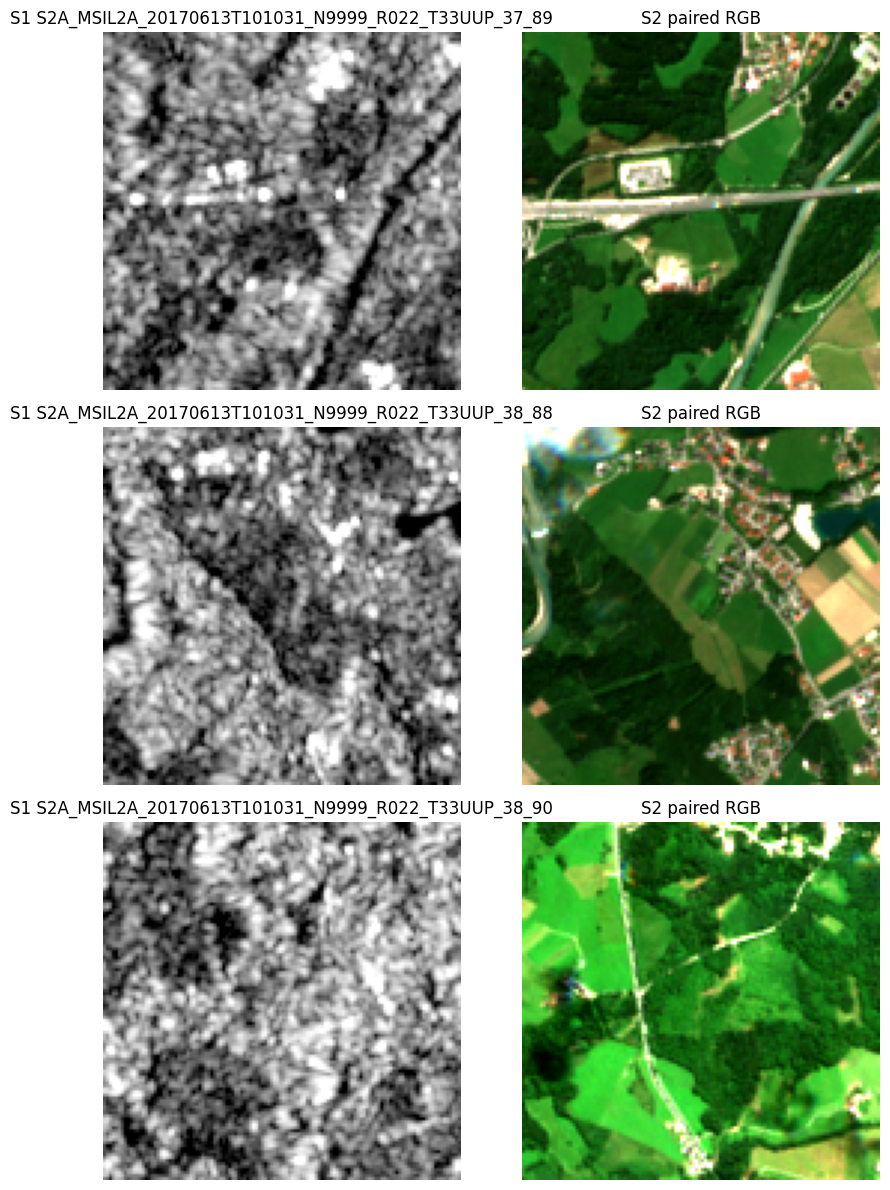

NameError: name 'tr' is not defined

In [18]:
fig,ax=plt.subplots(3,2,figsize=(9,12))
for i in range(3):
    q=train_ds[i]
    ax[i,0].imshow(sar(q["s1"]),cmap="gray")
    ax[i,1].imshow(rgb(q["s2"]))
    ax[i,0].set_title("S1 "+q["patch_id"])
    ax[i,1].set_title("S2 paired RGB")
    ax[i,0].axis("off")
    ax[i,1].axis("off")
plt.tight_layout()
plt.savefig(RUN_DIR/"data_check.png",dpi=140); plt.show()
print("train/val/test",len(train_ds),len(val_ds),len(test_ds))

## 4. Model

In [19]:
REGISTRY = {
    "resnet18": "resnet18",
    "resnet34": "resnet34",
    "resnet50": "resnet50",
    "efficientnet_b0": "efficientnet_b0",
    "convnext_tiny": "convnext_tiny",
    "vit_small_patch16_224": "vit_small_patch16_224",
    "swin_tiny_patch4_window7_224": "swin_tiny_patch4_window7_224",
}


def resolved_model_name():
    return REGISTRY.get(cfg.MODEL_NAME, cfg.MODEL_NAME)


def create_backbone(
    in_channels,
    pretrained=False,
    model_name=None,
    image_size=None
):
    """
    Create a timm feature backbone.

    num_classes=0 removes the classification head and returns
    penultimate features.
    """
    name = model_name or resolved_model_name()

    kwargs = {
        "pretrained": pretrained,
        "in_chans": in_channels,
        "num_classes": 0
    }

    # Only override the configured model resolution when necessary.
    # For reBEN checkpoints, architecture settings should come from
    # the checkpoint configuration whenever available.
    if image_size is not None:
        kwargs["img_size"] = image_size

    try:
        model = timm.create_model(name, **kwargs)

        initialization = (
            "timm_pretrained"
            if pretrained
            else "random"
        )

        return model, initialization

    except Exception as error:
        if not pretrained:
            raise RuntimeError(
                f"Could not create random backbone {name!r} "
                f"with {in_channels} channels."
            ) from error

        print(
            f"Generic pretrained initialization failed for {name}: "
            f"{error}"
        )
        print("Falling back to random initialization.")

        kwargs["pretrained"] = False

        model = timm.create_model(name, **kwargs)

        return model, "random_fallback"

In [21]:
backbone, initialization = create_backbone(
    in_channels=len(S1_BANDS),
    pretrained=True
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [25]:
backbone, initialization = create_backbone(
    in_channels=len(S2_BANDS),
    pretrained=True,
    image_size=cfg.IMAGE_SIZE
)

In [ ]:
REGISTRY={
    "resnet18":"resnet18",
    "resnet34":"resnet34",
    "resnet50":"resnet50",
    "efficientnet_b0":"efficientnet_b0",
    "convnext_tiny":"convnext_tiny",
    "vit_small_patch16_224":"vit_small_patch16_224",
    "swin_tiny_patch4_window7_224":"swin_tiny_patch4_window7_224",
}
def backbone(ch,pretrained):
    name=REGISTRY.get(cfg.MODEL_NAME,cfg.MODEL_NAME)
    kw=dict(
        pretrained=pretrained,
        in_chans=ch,num_classes=0)
    if any(x in name for x in ("vit","swin","beit","deit")): 
        kw["img_size"]=cfg.IMAGE_SIZE
    try: 
        return timm.create_model(name,**kw),("timm_pretrained" if pretrained else "random")
    except Exception as e:
        print("Pretrained failed; training from random:",e)
        kw["pretrained"]=False
        return timm.create_model(name,**kw),"random_fallback"
class Encoder(nn.Module):
    def __init__(self, backbone, embed_dim):
        super().__init__()

        self.backbone = backbone

        if not hasattr(backbone, "num_features"):
            raise AttributeError(
                "Backbone does not expose num_features."
            )

        feature_dim = int(backbone.num_features)

        self.projector = nn.Sequential(
            nn.Linear(feature_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim)
        )

    def forward(self, x):
        features = self.backbone(x)

        if isinstance(features, (tuple, list)):
            if len(features) != 1:
                raise RuntimeError(
                    "Backbone returned multiple feature tensors. "
                    "Configure the backbone to return a single pooled feature."
                )
            features = features[0]

        if features.ndim != 2:
            raise RuntimeError(
                "Expected pooled backbone output with shape [B, F], "
                f"but received {tuple(features.shape)}."
            )

        embeddings = self.projector(features)

        return F.normalize(
            embeddings,
            p=2,
            dim=-1
        )
        
class Dual(nn.Module):
    def __init__(self):
        super().__init__()

        # Generic ImageNet initialization should not be used when
        # an exact reBEN checkpoint will subsequently be loaded.
        use_generic = (
            cfg.USE_GENERIC_PRETRAINED
            and not cfg.USE_HF_REBEN
        )

        s1_backbone, s1_init = create_backbone(
            in_channels=len(S1_BANDS),
            pretrained=use_generic
        )

        s2_backbone, s2_init = create_backbone(
            in_channels=len(S2_BANDS),
            pretrained=use_generic
        )

        self.s1_encoder = Encoder(
            s1_backbone,
            cfg.EMBED_DIM
        )

        self.s2_encoder = Encoder(
            s2_backbone,
            cfg.EMBED_DIM
        )

        self.initialization = {
            "s1": s1_init,
            "s2": s2_init,
            "s1_projector": "random",
            "s2_projector": "random"
        }

    def forward(self, s1, s2):
        s1_embedding = self.s1_encoder(s1)
        s2_embedding = self.s2_encoder(s2)

        return s1_embedding, s2_embedding

    def encode_s1(self, s1):
        return self.s1_encoder(s1)

    def encode_s2(self, s2):
        return self.s2_encoder(s2)
        
def extract_state_dict(checkpoint):
    """
    Extract a tensor state dictionary from common checkpoint formats.
    """
    if not isinstance(checkpoint, dict):
        raise TypeError(
            f"Expected checkpoint dictionary, got {type(checkpoint)}"
        )

    for key in (
        "state_dict",
        "model_state_dict",
        "model",
        "network",
        "net"
    ):
        candidate = checkpoint.get(key)

        if isinstance(candidate, dict):
            checkpoint = candidate
            break

    state_dict = {
        str(key): value
        for key, value in checkpoint.items()
        if torch.is_tensor(value)
    }

    if not state_dict:
        raise ValueError(
            "Checkpoint contains no tensor state dictionary."
        )

    return state_dict


def strip_known_prefixes(key):
    """
    Repeatedly remove common wrapper prefixes from a state-dict key.
    """
    prefixes = (
        "module.",
        "model.",
        "network.",
        "net."
    )

    changed = True

    while changed:
        changed = False

        for prefix in prefixes:
            if key.startswith(prefix):
                key = key[len(prefix):]
                changed = True
                break

    return key


def safe_torch_load(path):
    """
    Load a PyTorch checkpoint using weights_only when supported.
    """
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=True
        )
    except TypeError:
        # Compatibility with older PyTorch releases.
        return torch.load(
            path,
            map_location="cpu"
        )


def local_load(model, path, min_coverage=0.80):
    report = {
        "path": str(path) if path else None,
        "accepted": False,
        "coverage": 0.0,
        "matched_tensors": 0,
        "missing_tensors": 0,
        "unexpected_tensors": 0
    }

    if not path:
        report["reason"] = "No local checkpoint was configured."
        return report

    path = Path(path)

    if not path.is_file():
        report["reason"] = f"Checkpoint not found: {path}"
        return report

    checkpoint = safe_torch_load(path)
    source = extract_state_dict(checkpoint)

    source = {
        strip_known_prefixes(key): value
        for key, value in source.items()
    }

    target = model.state_dict()

    matched = {}

    for target_key, target_tensor in target.items():
        clean_target_key = strip_known_prefixes(target_key)

        if clean_target_key not in source:
            continue

        source_tensor = source[clean_target_key]

        if source_tensor.shape != target_tensor.shape:
            continue

        matched[target_key] = source_tensor

    target_parameters = sum(
        tensor.numel()
        for tensor in target.values()
    )

    matched_parameters = sum(
        tensor.numel()
        for tensor in matched.values()
    )

    coverage = (
        matched_parameters / target_parameters
        if target_parameters
        else 0.0
    )

    report["coverage"] = coverage
    report["matched_tensors"] = len(matched)
    report["missing_tensors"] = len(target) - len(matched)
    report["unexpected_tensors"] = len(source) - len(matched)

    if coverage < min_coverage:
        report["reason"] = (
            f"Coverage {coverage:.2%} is below the required "
            f"{min_coverage:.2%}; existing initialization retained."
        )
        return report

    incompatible = model.load_state_dict(
        matched,
        strict=False
    )

    report["missing_keys"] = list(incompatible.missing_keys)
    report["unexpected_keys"] = list(incompatible.unexpected_keys)
    report["accepted"] = True
    report["reason"] = "Checkpoint loaded."

    if hasattr(model, "initialization"):
        model.initialization = {
            "s1": "local_checkpoint",
            "s2": "local_checkpoint",
            "s1_projector": "local_checkpoint",
            "s2_projector": "local_checkpoint"
        }

    return report

In [ ]:
model=Dual()
if cfg.USE_HF_REBEN:
    s1_report=load_reben_encoder(model.s1_encoder,cfg.HF_S1_REPO,"s1")
    s2_report=load_reben_encoder(model.s2_encoder,cfg.HF_S2_REPO,"s2")
    model.initialization={"s1":"HF_reBEN_v0.1.1","s2":"HF_reBEN_v0.1.1"}
    load_report={"accepted":True,"coverage":min(s1_report["coverage"],s2_report["coverage"]),"s1":s1_report,"s2":s2_report}
else:
    load_report=local_load(model,cfg.LOCAL_PRETRAINED_PATH)
model.to(DEVICE)
print(model.initialization,json.dumps(load_report,indent=2,default=str))

In [ ]:
def loss_fn(a,b,y):
    logits=a@b.T/cfg.TEMPERATURE
    t=torch.arange(len(a),device=a.device)
    paired=(F.cross_entropy(logits,t)+F.cross_entropy(logits.T,t))/2
    
    z=torch.cat([a,b])
    yy=torch.cat([y,y])
    sim=z@z.T/cfg.TEMPERATURE
    eye=torch.eye(len(z),device=z.device,dtype=torch.bool)
    pos=(yy@yy.T>0)&~eye
    sim=sim-sim.max(1,keepdim=True).values.detach()
    ex=torch.exp(sim)*~eye
    valid=pos.any(1)
    semantic=-torch.log(((ex*pos).sum(1).clamp_min(1e-12)/ex.sum(1).clamp_min(1e-12))[valid]).mean()
    return cfg.PAIRED_WEIGHT*paired+cfg.SEMANTIC_WEIGHT*semantic,paired,semantic
    
@torch.no_grad()
def val_loss():
    model.eval()
    total=n=0
    for q in val_loader:
        a,b,y=q["s1"].to(DEVICE),q["s2"].to(DEVICE),q["labels"].to(DEVICE)
        z1,z2=model(a,b)
        l,_,_=loss_fn(z1,z2,y)
        total+=l.item()*len(a); n+=len(a)
    return total/max(n,1)
    
BEST=cfg.CKPT_DIR/f"{RUN_NAME}_best.pth"; LAST=cfg.CKPT_DIR/f"{RUN_NAME}_last.pth"
history=[]
def train():
    global history
    opt=torch.optim.AdamW(model.parameters(),lr=cfg.LR,weight_decay=cfg.WEIGHT_DECAY); sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,cfg.EPOCHS)
    scaler=torch.amp.GradScaler("cuda",enabled=DEVICE.type=="cuda"); start=0; best=float("inf"); stale=0
    if cfg.RESUME and LAST.exists():
        p=torch.load(LAST,map_location=DEVICE); model.load_state_dict(p["model_state_dict"]); opt.load_state_dict(p["optimizer"]); sch.load_state_dict(p["scheduler"]); history=p["history"]; start=p["epoch"]+1; best=p["best"]
    for ep in range(start,cfg.EPOCHS):
        model.train(); total=n=0
        for q in tqdm(train_loader,desc=f"epoch {ep+1}"):
            a,b,y=q["s1"].to(DEVICE),q["s2"].to(DEVICE),q["labels"].to(DEVICE); opt.zero_grad(set_to_none=True)
            with torch.autocast(DEVICE.type,dtype=torch.float16,enabled=DEVICE.type=="cuda"): z1,z2=model(a,b); l,pl,sl=loss_fn(z1,z2,y)
            scaler.scale(l).backward(); scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(),1.); scaler.step(opt); scaler.update()
            total+=l.item()*len(a); n+=len(a)
        v=val_loss(); sch.step(); row={"epoch":ep+1,"train_loss":total/n,"val_loss":v,"lr":opt.param_groups[0]["lr"]}; history.append(row)
        payload={"epoch":ep,"model_state_dict":model.state_dict(),"optimizer":opt.state_dict(),"scheduler":sch.state_dict(),"history":history,"best":min(best,v),"config":{k:str(x) if isinstance(x,Path) else x for k,x in asdict(cfg).items()},"initialization":model.initialization}
        torch.save(payload,LAST)
        if v<best: best=v; stale=0; torch.save(payload,BEST)
        else: stale+=1
        pd.DataFrame(history).to_csv(RUN_DIR/"history.csv",index=False); print(row)
        if stale>=cfg.PATIENCE: break
if cfg.RUN_TRAINING: 
    train()
if BEST.exists(): 
    model.load_state_dict(torch.load(BEST,map_location=DEVICE)["model_state_dict"])
if history:
    pd.DataFrame(history).plot(x="epoch",y=["train_loss","val_loss"],marker="o")
    plt.grid(alpha=.3)
    plt.savefig(RUN_DIR/"history.png",dpi=150)
    plt.show()

## 5. Retrieval evaluation and experiment comparison

In [ ]:
@torch.no_grad()
def embeddings():
    model.eval()
    a=[]
    b=[]
    y=[]
    ids=[]
    tic=time.perf_counter()
    for q in tqdm(test_loader):
        z1,z2=model(q["s1"].to(DEVICE),q["s2"].to(DEVICE))
        a.append(z1.cpu())
        b.append(z2.cpu())
        y.append(q["labels"])
        ids+=q["patch_id"]
    return {
        "s1":torch.cat(a),
        "s2":torch.cat(b),
        "labels":torch.cat(y),
        "ids":ids,
        "throughput":2*len(ids)/(time.perf_counter()-tic),
    }
    

In [ ]:
E=embeddings()
D={
    "s1_to_s1":("s1","s1",True),
    "s2_to_s2":("s2","s2",True),
    "s1_to_s2":("s1","s2",False),
    "s2_to_s1":("s2","s1",False),
}
directions=list(D) if cfg.TASK_MODE=="all" else [cfg.TASK_MODE]
def evaluate(name):
    qn,gn,same=D[name]
    q,g,y=E[qn],E[gn],E["labels"]
    sums=defaultdict(float)
    preds=[]; lat=[]
    maxk=min(10,len(g)-(1 if same else 0))
    gd=g.to(DEVICE)
    yd=y.to(DEVICE)
    for st in range(0,len(q),cfg.SIM_CHUNK):
        en=min(st+cfg.SIM_CHUNK,len(q))
        qq=q[st:en].to(DEVICE)
        qy=y[st:en].to(DEVICE)
        if DEVICE.type=="cuda": 
            torch.cuda.synchronize()
        tic=time.perf_counter()
        score=qq@gd.T
        if same: 
            score[torch.arange(en-st),torch.arange(st,en,device=DEVICE)]=-torch.inf
        val,ind=score.topk(maxk,dim=1)
        if DEVICE.type=="cuda": 
            torch.cuda.synchronize()
        lat += [(time.perf_counter()-tic)/(en-st)]*(en-st)
        allrel=qy@yd.T>0
        if same: 
            allrel[torch.arange(en-st),torch.arange(st,en,device=DEVICE)]=False
        rel=allrel.gather(1,ind)
        total=allrel.sum(1).clamp_min(1)
        for requested in (5,10):
            k=min(requested,maxk)
            hit=rel[:,:k].sum(1).float()
            p=hit/k; r=hit/total
            f=2*p*r/(p+r).clamp_min(1e-12)
            rr=rel[:,:k].float()
            pp=rr.cumsum(1)/torch.arange(1,k+1,device=DEVICE)
            ap=(pp*rr).sum(1)/torch.minimum(total,torch.tensor(k,device=DEVICE))
            for key,x in ((f"precision@{requested}",p),(f"recall@{requested}",r),(f"f1@{requested}",f),(f"map@{requested}",ap)): 
                sums[key]+=x.sum().item()
        for i in range(en-st): 
            preds.append({
                "direction":name,
                "query_id":E["ids"][st+i],
                "gallery_ids":[E["ids"][j] for j in ind[i].cpu().tolist()],
                "scores":val[i].cpu().tolist(),
                "relevant":rel[i].cpu().tolist()
            })
    out={k:v/len(q) for k,v in sums.items()}
    out.update(direction=name,mean_latency_ms=np.mean(lat)*1000,median_latency_ms=np.median(lat)*1000,embedding_throughput=E["throughput"])
    return out,preds
    
metrics=[]
predictions=[]
for d in directions:
    a,b=evaluate(d)
    metrics.append(a)
    predictions+=b
M=pd.DataFrame(metrics)
display(M)
M.to_csv(RUN_DIR/"retrieval_metrics.csv",index=False)

with open(RUN_DIR/"top10_predictions.jsonl","w") as f:
    for x in predictions:
        f.write(json.dumps(x)+"\n")
summary={
    "run_name":RUN_NAME,
    "model":cfg.MODEL_NAME,
    "initialization":json.dumps(model.initialization),
    "weight_coverage":load_report["coverage"],
    "f1@5":M["f1@5"].mean(),
    "f1@10":M["f1@10"].mean(),
    "map@10":M["map@10"].mean(),
    "latency_ms":M["mean_latency_ms"].mean(),
    "epochs":len(history),
}
P=cfg.RESULTS_DIR/"experiment_summary.csv"
old=pd.read_csv(P) if P.exists() else pd.DataFrame()
old=old[old.run_name!=RUN_NAME] if len(old) and "run_name" in old else old
comparison=pd.concat([old,pd.DataFrame([summary])],ignore_index=True).sort_values("f1@10",ascending=False)
comparison.to_csv(P,index=False)
display(comparison)

In [ ]:
# Acceptance checks: deterministic inference, self exclusion, checkpoint strict reload.
model.eval()
with torch.no_grad(): 
    x1=model.s1_encoder(s["s1"].unsqueeze(0).to(DEVICE))
    x2=model.s1_encoder(s["s1"].unsqueeze(0).to(DEVICE))
assert torch.allclose(x1,x2,atol=1e-6)

for p in predictions:
    if p["direction"] in ("s1_to_s1","s2_to_s2"): 
        assert p["query_id"] not in p["gallery_ids"]
        
print("Smoke tests passed.")

## 6. Hugging Face Gradio Space ZIP

In [ ]:
SPACE=cfg.OUTPUT_DIR/"bigearthnet_retrieval_space"; shutil.rmtree(SPACE,ignore_errors=True); (SPACE/"previews").mkdir(parents=True); (SPACE/"examples").mkdir()
idx=np.linspace(0,len(test_ds)-1,min(cfg.GALLERY_EXPORT_SIZE,len(test_ds)),dtype=int); rows=[]; ga=[]; gb=[]
for j,i in enumerate(idx):
    x=test_ds[int(i)]; ga.append(E["s1"][i].numpy()); gb.append(E["s2"][i].numpy())
    n1=f"previews/s1_{j:04d}.png"; n2=f"previews/s2_{j:04d}.png"; Image.fromarray((sar(x["s1"])*255).astype("uint8")).save(SPACE/n1); Image.fromarray((rgb(x["s2"])*255).astype("uint8")).save(SPACE/n2)
    rows.append({"patch_id":x["patch_id"],"labels":json.dumps([LABELS[k] for k in x["labels"].nonzero().flatten()]),"s1_preview":n1,"s2_preview":n2})
np.savez_compressed(SPACE/"gallery_embeddings.npz",s1=np.stack(ga),s2=np.stack(gb)); pd.DataFrame(rows).to_csv(SPACE/"gallery_metadata.csv",index=False)
ex=test_ds[0]; np.savez_compressed(SPACE/"examples/s1_example.npz",image=raw(ex["s1"],S1_BANDS)); np.savez_compressed(SPACE/"examples/s2_example.npz",image=raw(ex["s2"],S2_BANDS))
ck=BEST if BEST.exists() else LAST
if not ck.exists(): torch.save({"model_state_dict":model.state_dict()},ck)
shutil.copy2(ck,SPACE/"best_model.pth")
conf={"model_name":cfg.MODEL_NAME,"embed_dim":cfg.EMBED_DIM,"image_size":cfg.IMAGE_SIZE,"s1_bands":S1_BANDS,"s2_bands":S2_BANDS,"mean":MEAN,"std":STD}
(SPACE/"config.json").write_text(json.dumps(conf,indent=2)); (SPACE/"labels.json").write_text(json.dumps(LABELS,indent=2))
MODEL_CODE=r'''import json
from pathlib import Path
import numpy as np, rasterio, timm, torch
from rasterio.enums import Resampling
import torch.nn as nn
import torch.nn.functional as F
R=Path(__file__).parent; C=json.loads((R/"config.json").read_text()); D=torch.device("cuda" if torch.cuda.is_available() else "cpu")
def bb(ch):
 k=dict(pretrained=False,in_chans=ch,num_classes=0)
 if any(x in C["model_name"] for x in ("vit","swin","beit","deit")): k["img_size"]=C["image_size"]
 return timm.create_model(C["model_name"],**k)
class E(nn.Module):
 def __init__(self,b): super().__init__(); self.backbone=b; self.projector=nn.Sequential(nn.Linear(b.num_features,C["embed_dim"]),nn.GELU(),nn.LayerNorm(C["embed_dim"]),nn.Linear(C["embed_dim"],C["embed_dim"]))
 def forward(self,x):
  z=self.backbone(x)
  if z.ndim>2: z=z.mean(tuple(range(2,z.ndim)))
  return F.normalize(self.projector(z),dim=-1)
class M(nn.Module):
 def __init__(self): super().__init__(); self.s1_encoder=E(bb(len(C["s1_bands"]))); self.s2_encoder=E(bb(len(C["s2_bands"])))
M0=M(); p=torch.load(R/"best_model.pth",map_location="cpu"); M0.load_state_dict(p.get("model_state_dict",p)); M0.to(D).eval()
def load(path,mod):
 bands=C["s1_bands"] if mod=="S1" else C["s2_bands"]; path=Path(path)
 if path.suffix.lower()==".npz":
  z=np.load(path); a=z["image"] if "image" in z else z[z.files[0]]
 else:
  with rasterio.open(path) as s: a=s.read(out_shape=(s.count,C["image_size"],C["image_size"]),out_dtype="float32",resampling=Resampling.nearest)
 a=np.asarray(a,dtype="float32")
 if a.ndim==3 and a.shape[-1]==len(bands): a=np.moveaxis(a,-1,0)
 if a.shape[0]!=len(bands): raise ValueError(f"{mod} needs {len(bands)} ordered bands")
 if a.shape[-2:]!=(C["image_size"],C["image_size"]): a=F.interpolate(torch.from_numpy(a)[None],size=(C["image_size"],C["image_size"]),mode="nearest")[0].numpy()
 mu=np.array([C["mean"][b] for b in bands])[:,None,None]; sd=np.array([C["std"][b] for b in bands])[:,None,None]
 return torch.tensor((a-mu)/sd,dtype=torch.float32)[None]
@torch.inference_mode()
def embed(path,mod): return (M0.s1_encoder if mod=="S1" else M0.s2_encoder)(load(path,mod).to(D)).cpu().numpy()[0]
'''
APP_CODE=r'''from pathlib import Path
import shutil, tempfile, zipfile
import gradio as gr, numpy as np, pandas as pd
from model import embed
R=Path(__file__).parent; meta=pd.read_csv(R/"gallery_metadata.csv"); em=np.load(R/"gallery_embeddings.npz")
def user_gallery(path,mod):
 temp=Path(tempfile.mkdtemp(prefix="ben_gallery_"))
 with zipfile.ZipFile(path) as z:
  for item in z.infolist():
   target=(temp/item.filename).resolve()
   if temp.resolve() not in target.parents and target!=temp.resolve(): raise ValueError("Unsafe ZIP path")
  z.extractall(temp)
 files=sorted(x for x in temp.rglob("*") if x.suffix.lower() in (".npz",".tif",".tiff"))
 vectors=[]; names=[]
 for x in files:
  try: vectors.append(embed(x,mod)); names.append(x.stem)
  except Exception as exc: print("Skipping",x,exc)
 if not vectors: shutil.rmtree(temp,ignore_errors=True); raise ValueError("No valid full-band gallery files")
 return np.stack(vectors),names,temp
def search(q,qmod,gmod,k,gzip):
 if q is None: raise gr.Error("Upload full-band NPZ or GeoTIFF")
 z=embed(q,qmod); cleanup=None
 if gzip:
  vectors,names,cleanup=user_gallery(gzip,gmod); scores=vectors@z; ix=np.argsort(-scores)[:int(k)]
  table=[[n+1,names[i],float(scores[i]),"user gallery"] for n,i in enumerate(ix)]; gallery=[]
 else:
  scores=em[gmod.lower()]@z; ix=np.argsort(-scores)[:int(k)]; pc="s1_preview" if gmod=="S1" else "s2_preview"
  table=[[n+1,meta.iloc[i].patch_id,float(scores[i]),meta.iloc[i].labels] for n,i in enumerate(ix)]
  gallery=[(str(R/meta.iloc[i][pc]),f"#{n+1} {meta.iloc[i].patch_id}") for n,i in enumerate(ix)]
 if cleanup: shutil.rmtree(cleanup,ignore_errors=True)
 return table,gallery
with gr.Blocks() as demo:
 gr.Markdown("# BigEarthNet Cross-Modal Retrieval")
 with gr.Row(): q=gr.File(label="Full-band NPZ/GeoTIFF"); gzip=gr.File(label="Optional gallery ZIP")
 with gr.Row(): qm=gr.Radio(["S1","S2"],value="S2",label="Query"); gm=gr.Radio(["S1","S2"],value="S1",label="Gallery"); k=gr.Slider(1,10,5,step=1)
 go=gr.Button("Retrieve"); out=gr.Dataframe(headers=["Rank","Patch ID","Score","Labels"]); gal=gr.Gallery(columns=5)
 gr.Examples([[str(R/"examples/s2_example.npz"),"S2","S1",5,None],[str(R/"examples/s1_example.npz"),"S1","S2",5,None]],inputs=[q,qm,gm,k,gzip])
 go.click(search,[q,qm,gm,k,gzip],[out,gal])
demo.launch()
'''
(SPACE/"model.py").write_text(MODEL_CODE); (SPACE/"app.py").write_text(APP_CODE)
(SPACE/"requirements.txt").write_text("torch>=2.2\ntimm>=1.0.15\ngradio>=4.44\nrasterio>=1.3\npandas>=2\nnumpy>=1.24\n")
(SPACE/"README.md").write_text("---\ntitle: BigEarthNet Cross-Modal Retrieval\nemoji: 🛰️\nsdk: gradio\napp_file: app.py\npinned: false\n---\n\nS1/S2 retrieval demo using a fine-tuned reBEN ViT checkpoint, with a bundled compact gallery and full-band upload examples.")
ZIP=cfg.OUTPUT_DIR/"bigearthnet_retrieval_space.zip"
with zipfile.ZipFile(ZIP,"w",zipfile.ZIP_DEFLATED) as z:
    for p in SPACE.rglob("*"):
        if p.is_file(): z.write(p,p.relative_to(SPACE))
with zipfile.ZipFile(ZIP) as z:
    required={"app.py","model.py","best_model.pth","config.json","gallery_embeddings.npz","gallery_metadata.csv","README.md","requirements.txt"}
    assert not required-set(z.namelist()) and z.testzip() is None
print("Ready:",ZIP,ZIP.stat().st_size/1e6,"MB")

In [13]:
%%writefile {ROOT_DIR}/TerraSynapse/config/config.py
"""
config.py
All paths, hyperparameters, and the SWITCHABLE PRETRAINED MODEL LIST live here.
This file is imported by every other module — never hardcode paths elsewhere.
"""

import os
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════
# ENVIRONMENT SWITCH — change this one line when moving AWS → Kaggle
# ════════════════════════════════════════════════════════════════════════
ENV = os.getenv("BEN_ENV", "kaggle")

if ENV == "ec2":
    DATA_ROOT  = Path.home() / "ben_subset_data"
    OUTPUT_DIR = Path.home() / "TerraSynapse_outputs"
elif ENV == "kaggle":
    DATA_ROOT  = Path("/kaggle/input/datasets/glitchr/bigearthnet-48k-subset")
    OUTPUT_DIR = Path("/kaggle/working/outputs")
else:
    DATA_ROOT = Path(__file__).resolve().parents[1] / "deploy" / "artifacts"
    OUTPUT_DIR = DATA_ROOT

S1_ROOT  = DATA_ROOT / "BigEarthNet-S1"
S2_ROOT  = DATA_ROOT / "BigEarthNet-S2"
METADATA = DATA_ROOT / "ben_subset.csv"
CKPT_DIR = OUTPUT_DIR / "checkpoints"
PLOTS_DIR = OUTPUT_DIR / "sanity_check_plots"
RESULTS_DIR = OUTPUT_DIR / "results"

for d in [OUTPUT_DIR, CKPT_DIR, PLOTS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════
# PRETRAINED BACKBONE REGISTRY  (configilm / BigEarthNet v2.0 weights)
# ════════════════════════════════════════════════════════════════════════
# These are loaded via:
#   configilm.ConfigILM.ConfigILM + the config.json/model.safetensors files
#   downloaded from each Hugging Face repository. The reBEN Lightning wrapper
#   is not required.
#
# IMPORTANT: verify the exact repo id strings on the model hub before running —
# https://huggingface.co/BIFOLD-BigEarthNetv2-0
# Repo ids occasionally get renamed between releases, and the list below is only
# as accurate as the day it was written. Treat it as a starting point, not gospel.
#
# Pick ONE entry per modality per run via BACKBONE_S1 / BACKBONE_S2 below.
# To try a different backbone, just change the string — nothing else changes.

S2_BACKBONE_REGISTRY = {
    "resnet50":   "BIFOLD-BigEarthNetv2-0/resnet50-s2-v0.2.0",
    "resnet101":  "BIFOLD-BigEarthNetv2-0/resnet101-s2-v0.2.0",
    "resnet152":  "BIFOLD-BigEarthNetv2-0/resnet152-s2-v0.2.0",
    "vit_small":  "BIFOLD-BigEarthNetv2-0/vit_small_patch16_224-s2-v0.2.0",
    "vit_tiny":   "BIFOLD-BigEarthNetv2-0/vit_tiny_patch16_224-s2-v0.2.0",
    "convnext":   "BIFOLD-BigEarthNetv2-0/convnext_base-s2-v0.2.0",
}

S1_BACKBONE_REGISTRY = {
    "resnet50":   "BIFOLD-BigEarthNetv2-0/resnet50-s1-v0.2.0",
    "resnet101":  "BIFOLD-BigEarthNetv2-0/resnet101-s1-v0.2.0",
    "resnet152":  "BIFOLD-BigEarthNetv2-0/resnet152-s1-v0.2.0",
    "vit_small":  "BIFOLD-BigEarthNetv2-0/vit_small_patch16_224-s1-v0.2.0",
    "vit_tiny":   "BIFOLD-BigEarthNetv2-0/vit_tiny_patch16_224-s1-v0.2.0",
    "convnext":   "BIFOLD-BigEarthNetv2-0/convnext_base-s1-v0.2.0",
}

OPTICAL_BACKBONE_REGISTRY = {
    "resnet50_imagenet": "torchvision://resnet50",
    "resnet101_imagenet": "torchvision://resnet101",
}

# ── ACTIVE SELECTION — change these two lines to swap backbones ──────────
BACKBONE_KEY_S1 = "resnet50"
BACKBONE_KEY_S2 = "resnet50"
BACKBONE_KEY_OPTICAL = "resnet50_imagenet"

BACKBONE_S1 = S1_BACKBONE_REGISTRY[BACKBONE_KEY_S1]
BACKBONE_S2 = S2_BACKBONE_REGISTRY[BACKBONE_KEY_S2]
BACKBONE_OPTICAL = OPTICAL_BACKBONE_REGISTRY[BACKBONE_KEY_OPTICAL]

# ════════════════════════════════════════════════════════════════════════
# Modality settings
# ════════════════════════════════════════════════════════════════════════
SAR_CHANNELS = 2          # VV, VH
OPTICAL_CHANNELS = 3
MS_CHANNELS  = 10         # B02 B03 B04 B05 B06 B07 B08 B8A B11 B12
PATCH_SIZE   = 120

MS_BANDS = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
OPTICAL_BANDS = ["B04", "B03", "B02"]
MODALITIES = ["SAR", "Optical", "Multispectral"]

# ════════════════════════════════════════════════════════════════════════
# Model / training hyperparameters
# ════════════════════════════════════════════════════════════════════════
EMBED_DIM        = 256          # output dim of the shared projection head
FREEZE_BACKBONE  = True         # True = use pretrained backbone as a fixed feature
                                 # extractor (fast, good for limited time/compute);
                                 # set False to fine-tune end-to-end if time allows

BATCH_SIZE       = 32
EPOCHS_PROJ_ONLY = 10            # train only the projection head (backbone frozen)
EPOCHS_FINETUNE  = 10            # optional second phase if FREEZE_BACKBONE=False
LR_PROJ          = 1e-3
LR_ENC           = 1e-5
MARGIN           = 0.3
CROSS_MODAL_RATIO = 0.5

TOP_K           = [5, 10]
N_QUERY_PER_CLS = 50

# ════════════════════════════════════════════════════════════════════════
# Classes
# ════════════════════════════════════════════════════════════════════════
KEEP_CLASSES = [
    "Arable land", "Broad-leaved forest", "Coniferous forest",
    "Mixed forest", "Pastures", "Urban fabric",
    "Industrial or commercial units", "Inland waters",
    "Complex cultivation patterns", "Transitional woodland, shrub",
]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(KEEP_CLASSES)}
N_CLASSES    = len(KEEP_CLASSES)

RANDOM_STATE = 42


Overwriting /kaggle/working//TerraSynapse/config/config.py


In [14]:
import sys, torch, pandas as pd
sys.path.insert(0, f"{ROOT_DIR}/TerraSynapse")
from torch.utils.data import DataLoader
from config.config import METADATA, BATCH_SIZE, BACKBONE_S1, BACKBONE_S2, BACKBONE_OPTICAL
from data.dataset import BigEarthMMDataset
from models.encoders import build_encoders, inspect_model_structure
from training.trainer import run_training, triplet_collate_fn
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from config.config import S1_ROOT
S1_ROOT

PosixPath('/kaggle/input/datasets/glitchr/bigearthnet-48k-subset/BigEarthNet-S1')

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for model_id in (BACKBONE_S1, BACKBONE_OPTICAL, BACKBONE_S2):
    inspect_model_structure(model_id)  # manually confirm all three architectures

config.json:   0%|          | 0.00/849 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/94.4M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/configilm/ConfigILM.py:143: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(


ConfigILM(
  (vision_encoder): ResNet(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act2): ReLU(inplace=True)
        (aa): Identity()
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e

100%|██████████| 97.8M/97.8M [00:00<00:00, 145MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

config.json:   0%|          | 0.00/850 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/94.5M [00:00<?, ?B/s]

ConfigILM(
  (vision_encoder): ResNet(
    (conv1): Conv2d(10, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act2): ReLU(inplace=True)
        (aa): Identity()
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1

In [18]:
df

,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow,primary_label,labels_filtered,class_idx
0,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,['Arable land' 'Broad-leaved forest' 'Inland w...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_29_63,S2A_MSIL2A_20170613T101031_29_63,False,False,Arable land,"['Arable land', 'Broad-leaved forest', 'Inland...",0
1,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,['Arable land' 'Broad-leaved forest' 'Industri...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_30_53,S2A_MSIL2A_20170613T101031_30_53,False,False,Arable land,"['Arable land', 'Broad-leaved forest', 'Indust...",0
2,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,['Arable land' 'Broad-leaved forest' 'Industri...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_52,S2A_MSIL2A_20170613T101031_32_52,False,False,Arable land,"['Arable land', 'Broad-leaved forest', 'Indust...",0
3,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,['Arable land' 'Broad-leaved forest' 'Industri...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_53,S2A_MSIL2A_20170613T101031_32_53,False,False,Arable land,"['Arable land', 'Broad-leaved forest', 'Indust...",0
4,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,['Arable land' 'Complex cultivation patterns' ...,test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_62,S2A_MSIL2A_20170613T101031_32_62,False,False,Arable land,"['Arable land', 'Complex cultivation patterns'...",0
...,...,...,...,...,...,...,...,...,...,...,...
47493,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,['Arable land' 'Coniferous forest' 'Mixed fore...,train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_31,S2B_MSIL2A_20180525T094029_90_31,False,False,Arable land,"['Arable land', 'Coniferous forest', 'Mixed fo...",0
47494,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,['Coniferous forest' 'Mixed forest'],train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_33,S2B_MSIL2A_20180525T094029_90_33,False,False,Coniferous forest,"['Coniferous forest', 'Mixed forest']",2
47495,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,['Inland waters'],train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_47,S2B_MSIL2A_20180525T094029_90_47,False,False,Inland waters,['Inland waters'],7
47496,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,['Coniferous forest' 'Inland waters'\n 'Land p...,train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_58,S2B_MSIL2A_20180525T094029_90_58,False,False,Coniferous forest,"['Coniferous forest', 'Inland waters']",2


In [ ]:
df = pd.read_csv(METADATA)
train_ds, val_ds = BigEarthMMDataset(df, "train"), BigEarthMMDataset(df, "validation")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=triplet_collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=triplet_collate_fn)

In [ ]:
encoders = run_training(train_loader, val_loader, build_encoders(device), device)

/usr/local/lib/python3.12/dist-packages/configilm/ConfigILM.py:143: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(
[proj_only] Epoch 1/10:   0%|          | 0/722 [00:00<?, ?batch/s]


RasterioIOError: Caught RasterioIOError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "rasterio/_base.pyx", line 320, in rasterio._base.DatasetBase.__init__
  File "rasterio/_base.pyx", line 232, in rasterio._base.open_dataset
  File "rasterio/_err.pyx", line 359, in rasterio._err.exc_wrap_pointer
rasterio._err.CPLE_OpenFailedError: /kaggle/input/datasets/glitchr/bigearth-mm-subset-47k/BigEarthNet-S2/S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_88_80/S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_88_80_B02.tif: No such file or directory

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    da

In [13]:
df['patch_id'].nunique()

47498

In [16]:
df['s1_name'].nunique()

47498

In [17]:
df['s2v1_name'].nunique()

47498

In [14]:
df

,patch_id,s1_name,s2v1_name,split,country,primary_label,labels_str
0,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_29_63,S2A_MSIL2A_20170613T101031_29_63,test,Austria,Arable land,Arable land|Broad-leaved forest|Inland waters|...
1,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_30_53,S2A_MSIL2A_20170613T101031_30_53,test,Austria,Arable land,Arable land|Broad-leaved forest|Industrial or ...
2,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_52,S2A_MSIL2A_20170613T101031_32_52,test,Austria,Arable land,Arable land|Broad-leaved forest|Industrial or ...
3,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_53,S2A_MSIL2A_20170613T101031_32_53,test,Austria,Arable land,Arable land|Broad-leaved forest|Industrial or ...
4,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_3...,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_62,S2A_MSIL2A_20170613T101031_32_62,test,Austria,Arable land,Arable land|Complex cultivation patterns|Mixed...
...,...,...,...,...,...,...,...
47493,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_31,S2B_MSIL2A_20180525T094029_90_31,train,Finland,Arable land,Arable land|Coniferous forest|Mixed forest
47494,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_33,S2B_MSIL2A_20180525T094029_90_33,train,Finland,Coniferous forest,Coniferous forest|Mixed forest
47495,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_47,S2B_MSIL2A_20180525T094029_90_47,train,Finland,Inland waters,Inland waters
47496,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_58,S2B_MSIL2A_20180525T094029_90_58,train,Finland,Coniferous forest,Coniferous forest|Inland waters|Land principal...


In [11]:
for i in train_ds:
    break

RasterioIOError: /kaggle/input/datasets/glitchr/bigearth-mm-subset-47k/BigEarthNet-S2/S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_89/S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_89_B02.tif: No such file or directory